In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import networkx as nx
import os
import re
from scipy.spatial import distance
import math
from scipy.cluster import hierarchy
from argparse import Namespace
import matplotlib.pyplot as plt
import oslom
import scipy.stats as stats
import scipy
import random

sc.set_figure_params(dpi=80)

import seaborn as sns
plt.rcParams['axes.grid'] = False
fontsize = 16
plt.rcParams['xtick.labelsize'] = fontsize
plt.rcParams['ytick.labelsize'] = fontsize
plt.rcParams['axes.labelsize'] = fontsize
plt.rcParams['axes.labelsize'] = fontsize
plt.rcParams['axes.titlesize'] = fontsize

import matplotlib
from matplotlib.gridspec import GridSpec
from datetime import datetime
from matplotlib.ticker import FixedLocator, FixedFormatter
from tqdm import tqdm
matplotlib.rcParams["text.usetex"] = False
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['DejaVu Sans']})


In [ ]:
import importlib.util
import sys

def lazy_import(module_name, path_to_file):
    spec = importlib.util.spec_from_file_location(module_name,path_to_file)
    foo = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = foo
    spec.loader.exec_module(foo)
    return foo

utils_dir = "../../utils"
general_utils = lazy_import("general_utils",os.path.join(utils_dir, "general_utils.py"))
diffusion_utils = lazy_import("diffusion_utils",os.path.join(utils_dir, "diffusion_maps.py"))
thresholding_functions = lazy_import("thresholding_functions",os.path.join(utils_dir, "thresholding_functions.py"))

from general_utils import ismember, grep, grep_exclude, write_object, read_object
from diffusion_utils import get_diffusion_operator_from_knn, get_imputed_adata_subset
from thresholding_functions import threshold_triangle, threshold_otsu

Calligraphy code

In [ ]:
def initial_graph(corr_matrix,correlation_threshold,gene_list):    
    #create networkx graph G from thresholded correlation matrix
    G = nx.convert_matrix.from_numpy_array((corr_matrix>=correlation_threshold)*corr_matrix)
    #re-name nodes to gene names
    gene_mapping = {i:gene_list[i] for i in range(len(gene_list))}
    G = nx.relabel_nodes(G, gene_mapping, copy=True)
    return G

def refine_graph_jaccard(G,gene_list,corr_matrix,prune_thresh=.15,prune_thresh_upper = .85):
    gene_list = list(gene_list) #ensure this is a list and not an array for compatibility below
    Gpruned = G.copy()
    preds = nx.algorithms.link_prediction.jaccard_coefficient(G,G.edges)
    for u,v,p in preds:
        if p < prune_thresh:
            Gpruned.remove_edge(u, v)
    preds = nx.algorithms.link_prediction.jaccard_coefficient(G)
    for u,v,p in preds:
        if p > prune_thresh_upper:
            Gpruned.add_edge(u, v, weight=corr_matrix[gene_list.index(u),gene_list.index(v)])
    return Gpruned

def run_oslom(G):
    args = Namespace()
    args.min_cluster_size = 5
    args.oslom_args = oslom.DEF_OSLOM_ARGS
    
    #edited version of OSLOM to fix dependency issue
    args.oslom_exec = "/data/lowe/reyesj3/repositories/OSLOM2/oslom_undir"

    edges = G.edges.data("weight", default=1)
    clusters = oslom.run_in_memory(args,edges)
    
    clusters_ = [clusters[0]['clusters'][i]['nodes'] for i in range(len(clusters[0]['clusters']))]

    cliques_iterative = []
    for clust in clusters_:
        cliques_iterative.append([dict_['id'] for dict_ in clust])

    return cliques_iterative

def get_modules(corr_matrix, gene_list, correlation_threshold=.1,prune_thresh=.4,prune_thresh_upper = None):
    print("Constructing graph")
    G = initial_graph(corr_matrix,correlation_threshold,gene_list)
    print("Pruning graph")
    Gpruned = refine_graph_jaccard(G,gene_list,corr_matrix,prune_thresh=prune_thresh,prune_thresh_upper=prune_thresh_upper)
    print("Computing modules")
    cliques_communities = run_oslom(Gpruned)
    return cliques_communities, G, Gpruned

def show_correlation_heatmap(corr_matrix, ordering, cliques, use_labels = [], selected_type = '', save_plot = False):
    # Plot heatmap
    ncliques = len(cliques)
    fig, ax = plt.subplots(figsize=[6.5 + 0.5*ncliques,6.5],tight_layout=True, ncols=1 + ncliques, nrows=1, width_ratios=[5] + [0.3] * ncliques,height_ratios=[1], sharey = True)
    im = ax[0].imshow(corr_matrix.iloc[ordering,:].iloc[:,ordering], vmin = -1, vmax= 1, cmap = 'RdBu_r', interpolation = 'none', aspect = 'auto')
        
    reordered_labels = corr_matrix.index[ordering].tolist()
    use_ticks = [reordered_labels.index(label) + .5 for label in use_labels]
    ax[0].set(yticks=use_ticks, yticklabels=use_labels, xticks = [])
    ax[0].set_frame_on(True)
    ax[0].set_title('Correlation matrix')
    ax[0].set_xlabel('Communication genes (n=' + str(corr_matrix.shape[0]) + ')')
    
    colors = matplotlib.colormaps['Paired'].colors[:ncliques]
    rgb_cols = np.array([matplotlib.colors.to_rgb(x) for x in colors])
    gene_reordered = corr_matrix.index.to_numpy()[ordering]
    
    for j,clique in enumerate(range(len(cliques))):
        col_rgb_colors = np.array([rgb_cols[j,:] if gene in cliques[clique] else np.array([1,1,1]) for gene in gene_reordered])    
        ax[j+1].imshow(np.tile(col_rgb_colors[:, None, :], [1, 1000, 1]),aspect="auto")
        plt.box(on=True)
        ax[j+1].set_xticks([])
        #ax[j+2].set_yticks([])
    
    if save_plot:
        plt.savefig('Figures/Fig20251108_' + selected_type + '_communication_gene_correlation.pdf', dpi = 300)

Import communication genes

In [ ]:
import itertools
rl_database = pd.read_csv('../support/CellChatDB.ligrec.mouse.csv', sep = ",", index_col = 0)
rl_database = rl_database.loc[np.logical_not(ismember(rl_database.iloc[:,3], ['Cell-Cell Contact', 'ECM-Receptor'])[1]),:].copy()

ligands = [re.split("_", x) for x in rl_database.iloc[:,0]]
receptors = [re.split("_", x) for x in rl_database.iloc[:,1]]

ligand_receptor_pairs = []
for ligand_collection, receptor_collection in zip(ligands, receptors):
    ligand_receptor_pairs += list(itertools.product(ligand_collection, receptor_collection))
ligand_receptor_pairs = np.array(ligand_receptor_pairs)
ligand_receptor_pairs = np.unique(ligand_receptor_pairs, axis=0)

communication_genes = np.unique(np.ravel(ligand_receptor_pairs))
communication_genes = [x.upper() for x in communication_genes]

In [ ]:
output_dir = "../calligraphy"
os.makedirs(output_dir, exist_ok=True)


In [ ]:
def select_genes(adata, groupby = 'pheno_10', hist_bins = 100, MIN_DETECTION_LOCAL = 0.05, MIN_DETECTION_GLOBAL = 50, filter_global = False):
    selected_genes = adata.var_names[ismember(adata.var_names, communication_genes)[1]]
    df = pd.DataFrame(adata[:,selected_genes].layers['imputed'], index = adata.obs_names, columns = selected_genes)    
    df['pheno_10'] = adata.obs['pheno_10'].to_numpy()
    df = df.loc[df['pheno_10'] != -1,:].copy()
    df_summarized = df.groupby('pheno_10').agg('mean')

    max_val = df_summarized.max(axis=0)
    max_val = max_val[max_val <= np.quantile(max_val, 0.9)]
    h, bins = np.histogram(max_val, bins = hist_bins, density = True)
    my_threshold = threshold_triangle(h, bins)
    
    plt.stairs(h, bins, fill=True, color='gray')
    plt.xlim([0,0.5])
    plt.plot([my_threshold] * 2, plt.gca().get_ylim(), 'k--')
    plt.xlabel("maximum average imputed expression")
    plt.ylabel("density")

    selected_genes_imputed_expression = np.sort(df_summarized.columns[df_summarized.max(axis=0) > my_threshold].to_numpy())
    print("Imputed expression filter: " + str(len(selected_genes_imputed_expression)) + " genes")

    df = pd.DataFrame((adata[:,selected_genes].X.todense() > 0).astype(np.uint8), index = adata.obs_names, columns = selected_genes)
    df['pheno_10'] = adata.obs['pheno_10'].to_numpy()
    df = df.loc[df['pheno_10'] != -1,:].copy()
    df_summarized = df.groupby('pheno_10').agg('mean')
    max_detection_rate = df_summarized.max(axis=0)
    selected_genes_detected = np.sort(max_detection_rate[max_detection_rate >= MIN_DETECTION_LOCAL].index.to_numpy())
    print("Local detection filter: " + str(len(selected_genes_detected)) + " genes")

    detection_rate_global = np.ravel((adata[:,selected_genes].X.todense() > 0).astype(np.uint8).sum(axis=0)) > MIN_DETECTION_GLOBAL
    selected_genes_detected_global = np.sort(selected_genes[detection_rate_global])
    print("Global detection filter: " + str(len(selected_genes_detected_global)) + " genes")

    selected_final = np.intersect1d(selected_genes_imputed_expression, selected_genes_detected)
    if(filter_global):
        selected_final = np.intersect1d(np.intersect1d(selected_genes_imputed_expression, selected_genes_detected), selected_genes_detected_global)
    print("Final selected: " + str(len(selected_final)) + " genes")
    return(selected_final)
    

### Epithelial communication modules

In [ ]:
input_dir = "../data"
current_filename = "Reyes_injury_SUBSET_all__annotated.h5ad"
adata_epi2 = sc.read_h5ad(os.path.join(input_dir, current_filename))

In [ ]:
imputed_shRen = get_imputed_adata_subset(adata_epi2, adata_epi2.obs['genotype'] == 'shRen', k = 30, t_steps=2)
imputed_shp53 = get_imputed_adata_subset(adata_epi2, adata_epi2.obs['genotype'] == 'shp53', k = 30, t_steps=2)
imputed_adata = sc.concat([imputed_shRen, imputed_shp53])
imputed_adata.layers['zscore'] = np.array(imputed_adata.X.copy())
sc.pp.scale(imputed_adata, layer = 'zscore')

Getting knn graph


2026-03-05 19:07:56.520417: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-05 19:07:57.674694: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-05 19:07:57.674741: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-05 19:07:57.739882: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-05 19:07:57.773672: I tensorflow/core/platform/cpu_feature_guar

Getting diffusion operator
Computing diffusion kernel using CPU
Computing diffusion operator using CPU
Imputing data
Getting knn graph
Getting diffusion operator
Computing diffusion kernel using CPU
Computing diffusion operator using CPU
Imputing data


Imputed expression filter: 274 genes
Local detection filter: 320 genes
Global detection filter: 365 genes
Final selected: 271 genes


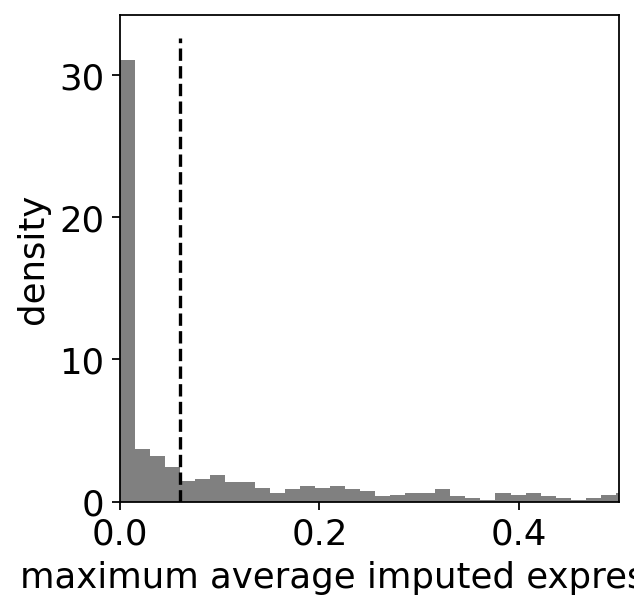

In [ ]:
adata_epi2.layers['imputed'] = imputed_adata[adata_epi2.obs_names,:].X.copy()
selected_genes = select_genes(adata_epi2, hist_bins=50, filter_global=True, MIN_DETECTION_GLOBAL=50)

In [ ]:
blacklisted_genes = ['CSF1R', 'CSF3R', 'PECAM1', 'CDH11']
selected_genes = selected_genes[np.logical_not(ismember(selected_genes, blacklisted_genes)[1])]

In [ ]:
X = imputed_adata[:, selected_genes].layers['zscore']
corr_mat = np.corrcoef(X.T)
corr_mat = pd.DataFrame(corr_mat, index = selected_genes, columns = selected_genes)
linkage = hierarchy.linkage(corr_mat, method = 'ward')
ordering = hierarchy.dendrogram(linkage, no_plot = True)['leaves']

Constructing graph
Pruning graph
Computing modules


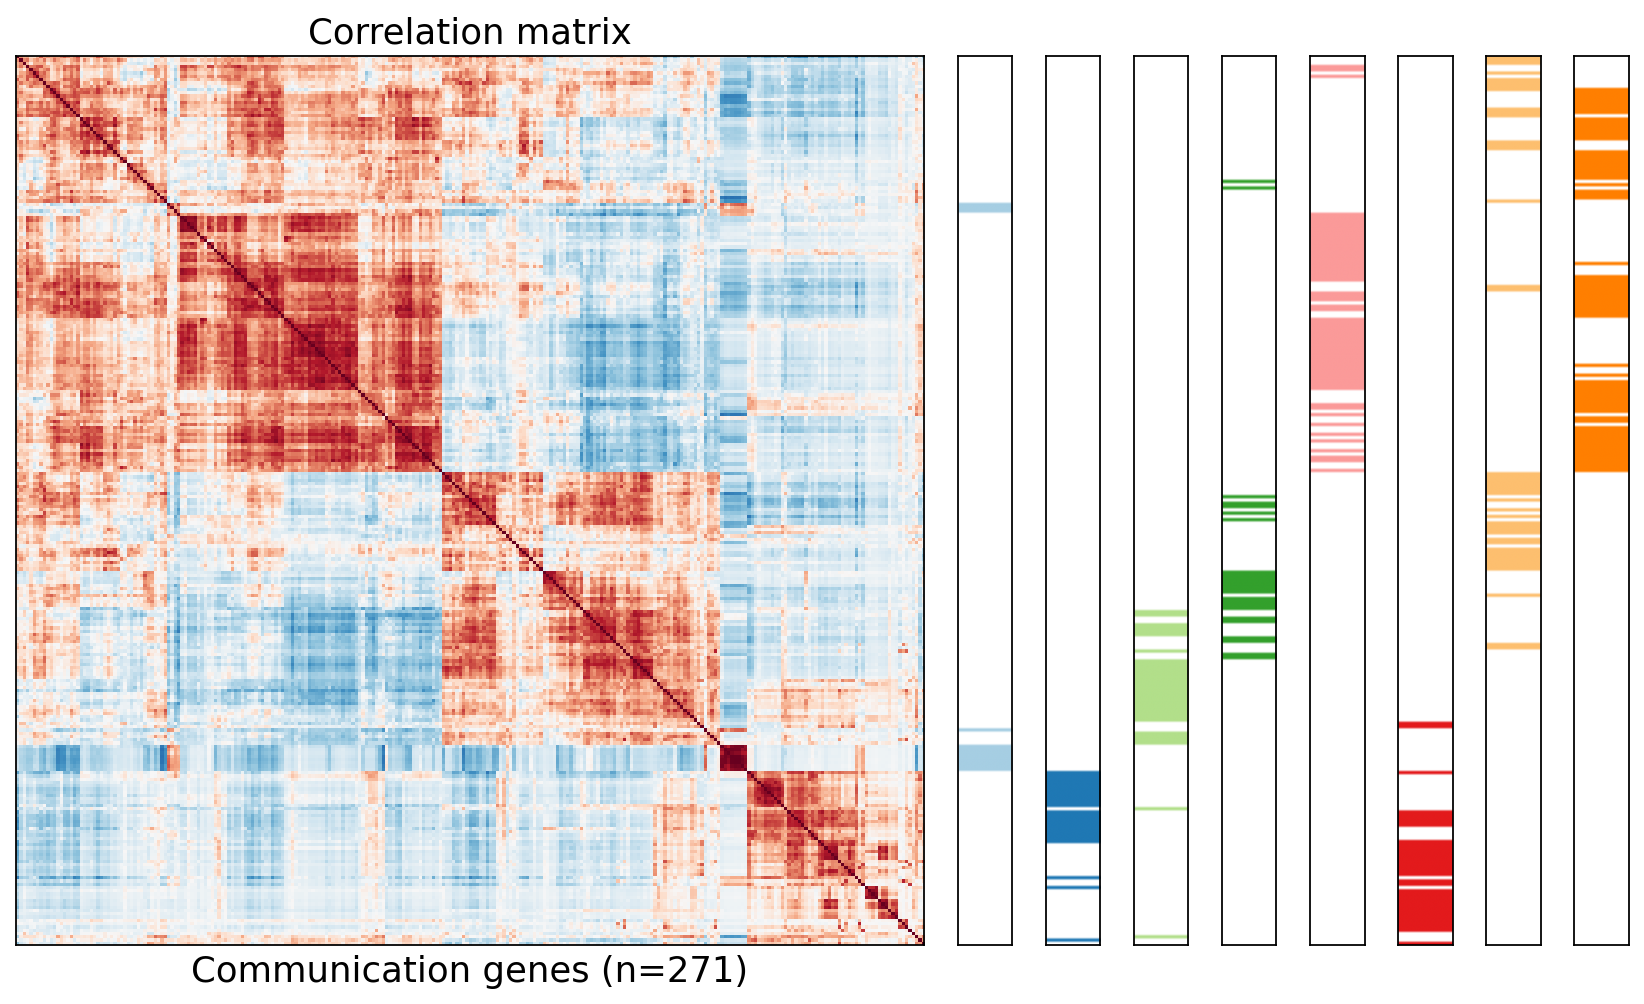

In [ ]:
cliques_iterative, G, Gpruned = get_modules(
    corr_mat.to_numpy(),corr_mat.index.to_numpy(),
    prune_thresh=0.05,prune_thresh_upper=0.95,correlation_threshold = 0.4
)
        
show_correlation_heatmap(
    corr_matrix = corr_mat, 
    ordering = ordering, 
    cliques = cliques_iterative, 
    use_labels = [], 
    selected_type = 'Epi', 
    save_plot = False
)

In [ ]:
adata_epi2.layers['imputed_zscore'] = adata_epi2.layers['imputed'].copy()
sc.pp.scale(adata_epi2, layer = 'imputed_zscore')
for i in range(len(cliques_iterative)):
    adata_epi2.obs['module_' + str(i).zfill(2)] = np.ravel(adata_epi2[:,cliques_iterative[i]].layers['imputed_zscore'].mean(axis=1))

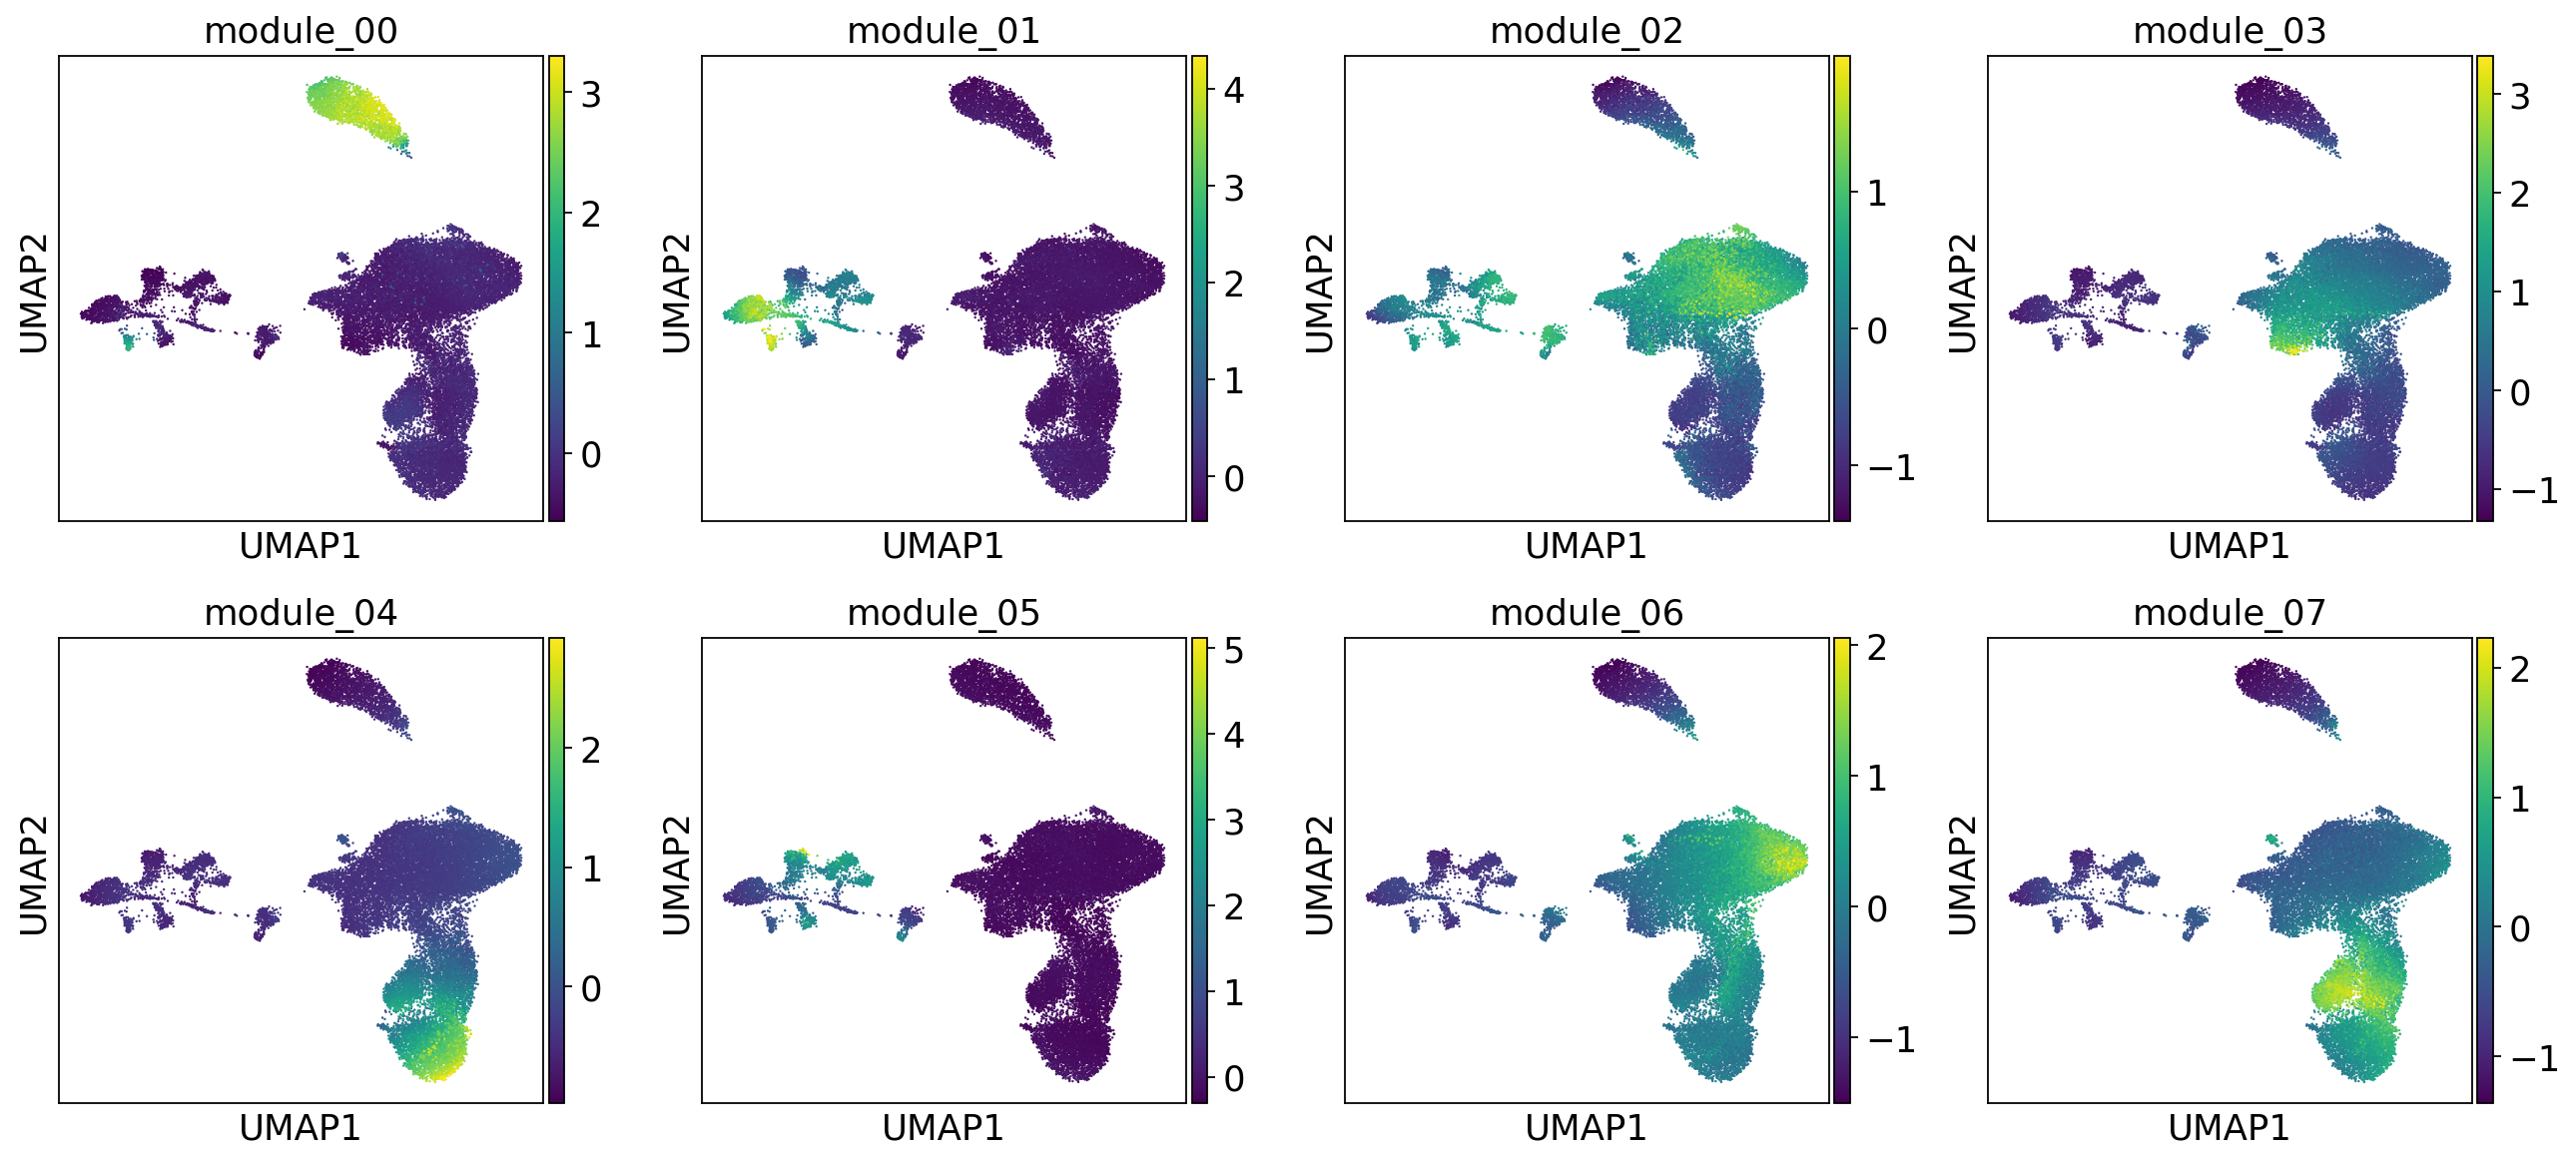

In [ ]:
sc.pl.umap(adata_epi2, color=[ 'module_00', 'module_01', 'module_02', 'module_03', 'module_04', 'module_05', 'module_06', 'module_07'])

In [ ]:
if 'imputed_zscore' in adata_epi.layers:
    del adata_epi2.layers['imputed_zscore']
adata_temp = adata_epi2[:, selected_genes].copy()
sc.write(os.path.join(output_dir, re.sub(".h5ad", "__imputed.h5ad", current_filename)), adata = adata_temp)
result = {
    'corr_mat': corr_mat,
    'ordering': ordering,
    'cliques_iterative': cliques_iterative,
    'G': G,
    'G_pruned': Gpruned
}
write_object(result, os.path.join(output_dir, re.sub(".h5ad", "__communication_modules.pydata", current_filename)))

### Myeloid communication modules

In [ ]:
current_filename = "Reyes_FLEX_SUBSET_TAM_all__integrated.h5ad"
adata_TAM = sc.read_h5ad(os.path.join(input_dir, current_filename))

In [ ]:
imputed_adata = get_imputed_adata_subset(adata_TAM, ismember(adata_TAM.obs['genotype'], ['ctrl', 'p53_knockdown'])[1], k = 30, t_steps = 2)
imputed_adata.layers['zscore'] = np.array(imputed_adata.X.copy())
sc.pp.scale(imputed_adata, layer = 'zscore')

Getting knn graph
Getting diffusion operator
Computing diffusion kernel using CPU
Using knn of size 29
Computing diffusion operator using CPU
Imputing data


Imputed expression filter: 176 genes
Local detection filter: 238 genes
Global detection filter: 232 genes
Final selected: 171 genes


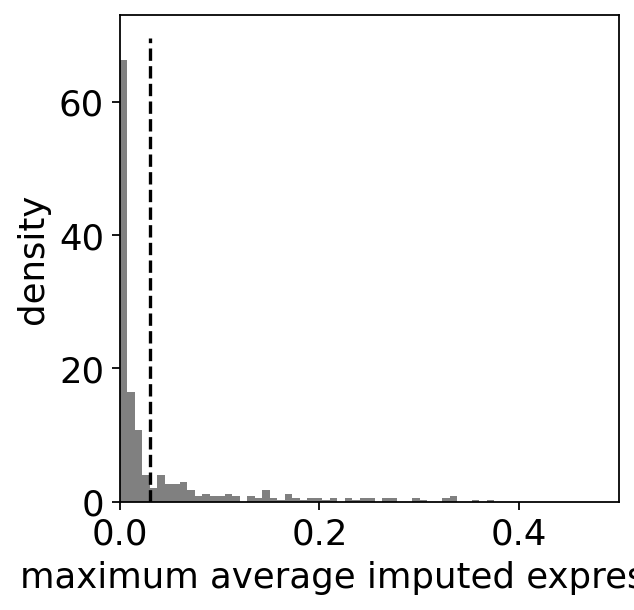

In [ ]:
adata_TAM.layers['imputed'] = imputed_adata[adata_TAM.obs_names,:].X.copy()
selected_genes = select_genes(adata_TAM, hist_bins = 50, MIN_DETECTION_LOCAL=0.05, filter_global=True, MIN_DETECTION_GLOBAL=50)

In [ ]:
selected_genes

array(['ACVR1', 'ACVR1B', 'ACVRL1', 'ADIPOR1', 'ADIPOR2', 'ANGPTL2',
       'ANGPTL4', 'ANXA1', 'AXL', 'BAG6', 'BMP2', 'BMPR1A', 'BMPR2', 'C3',
       'C3AR1', 'C4A', 'C4B', 'C5AR1', 'CALCRL', 'CAP1', 'CCL12', 'CCL17',
       'CCL2', 'CCL24', 'CCL4', 'CCL5', 'CCL6', 'CCL7', 'CCL8', 'CCL9',
       'CCR1', 'CCR2', 'CCR5', 'CD44', 'CD74', 'CDH11', 'CLCF1', 'CMKLR1',
       'CRLF2', 'CSF1R', 'CSF2RA', 'CSF2RB', 'CSF3R', 'CXCL12', 'CXCL13',
       'CXCL16', 'CXCR4', 'EBI3', 'EDNRB', 'FAS', 'FGFR1', 'FLT3L',
       'FPR1', 'FPR2', 'FZD1', 'FZD4', 'FZD7', 'GAS6', 'GDF10', 'GFRA2',
       'GHR', 'GRN', 'HAVCR2', 'HGF', 'IFNAR1', 'IFNAR2', 'IFNGR1',
       'IFNGR2', 'IGF1', 'IGF1R', 'IGF2', 'IGFLR1', 'IGHM', 'IL10RA',
       'IL10RB', 'IL13RA1', 'IL15', 'IL15RA', 'IL16', 'IL17RA', 'IL18',
       'IL18RAP', 'IL1A', 'IL1B', 'IL1R1', 'IL1RL1', 'IL1RL2', 'IL21R',
       'IL27RA', 'IL2RA', 'IL2RG', 'IL33', 'IL3RA', 'IL4RA', 'IL6RA',
       'IL6ST', 'IL7R', 'INS1', 'INS2', 'INSR', 'ITGA4', 'ITGA5', '

In [ ]:
blacklisted_genes = ['PECAM1', 'CDH11', 'CDH1', 'COL4A1', 'COL4A2']
selected_genes = selected_genes[np.logical_not(ismember(selected_genes, blacklisted_genes)[1])]

In [ ]:
X = imputed_adata[:, selected_genes].layers['zscore']
corr_mat = np.corrcoef(X.T)
corr_mat = pd.DataFrame(corr_mat, index = selected_genes, columns = selected_genes)
linkage = hierarchy.linkage(corr_mat, method = 'ward')
ordering = hierarchy.dendrogram(linkage, no_plot = True)['leaves']

Constructing graph
Pruning graph
Computing modules


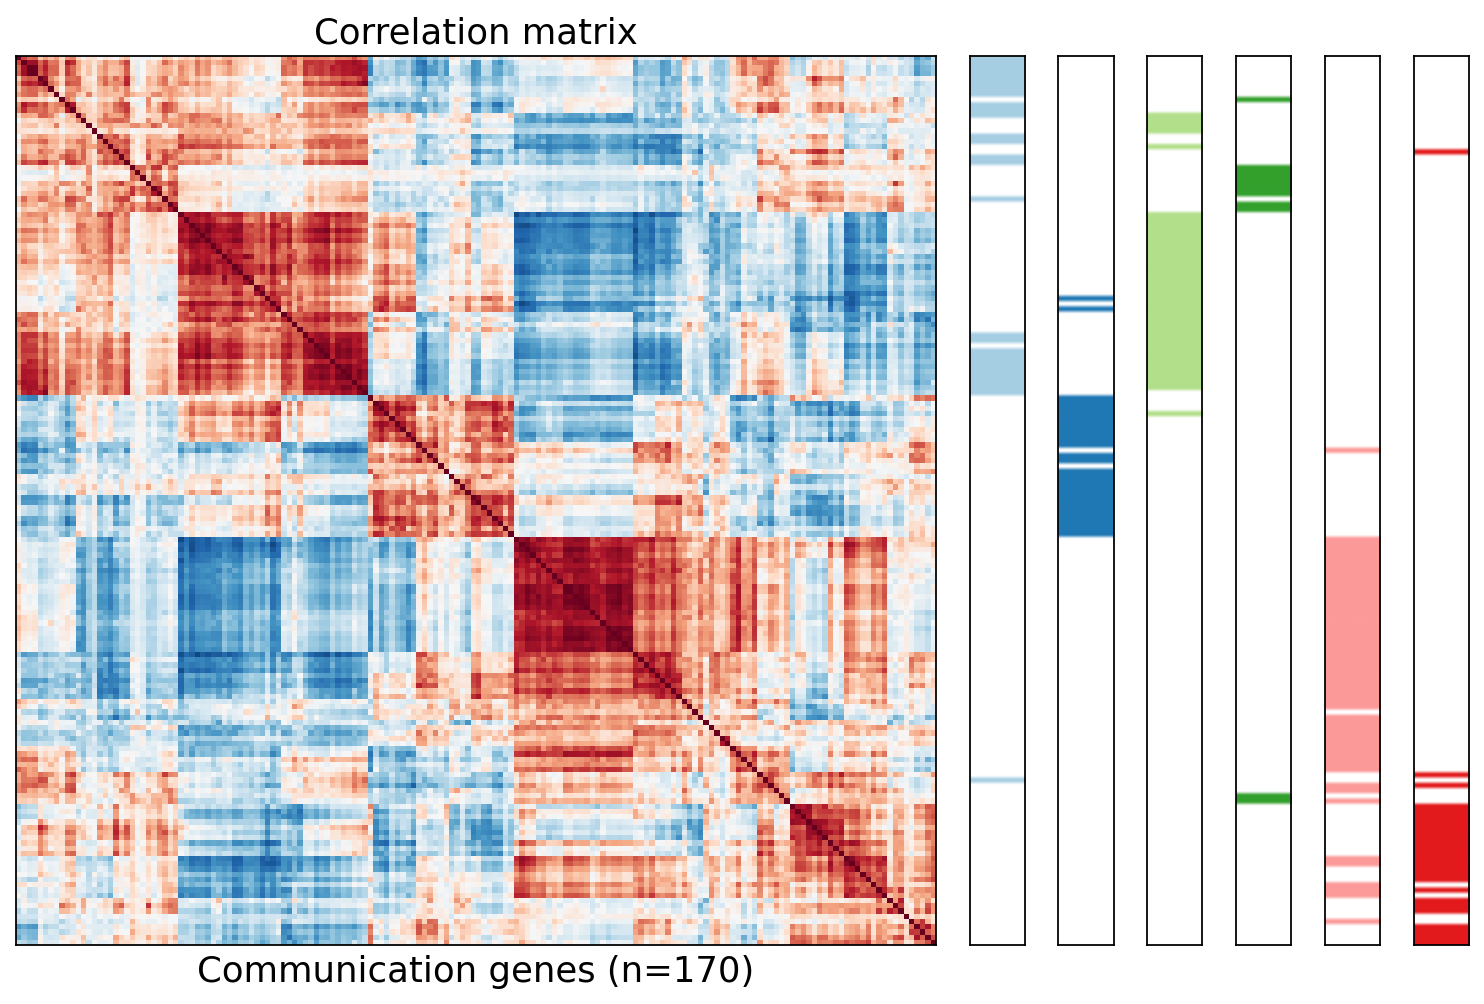

In [ ]:
cliques_iterative, G, Gpruned = get_modules(
    corr_mat.to_numpy(),corr_mat.index.to_numpy(),
    prune_thresh=0.05,prune_thresh_upper=0.95,correlation_threshold = 0.4
)
        
show_correlation_heatmap(
    corr_matrix = corr_mat, 
    ordering = ordering, 
    cliques = cliques_iterative, 
    use_labels = [], 
    selected_type = 'TAM', 
    save_plot = False
)

In [ ]:
adata_TAM.layers['imputed_zscore'] = adata_TAM.layers['imputed'].copy()
sc.pp.scale(adata_TAM, layer = 'imputed_zscore')
for i in range(len(cliques_iterative)):
    adata_TAM.obs['module_' + str(i).zfill(2)] = np.ravel(adata_TAM[:,cliques_iterative[i]].layers['imputed_zscore'].mean(axis=1))

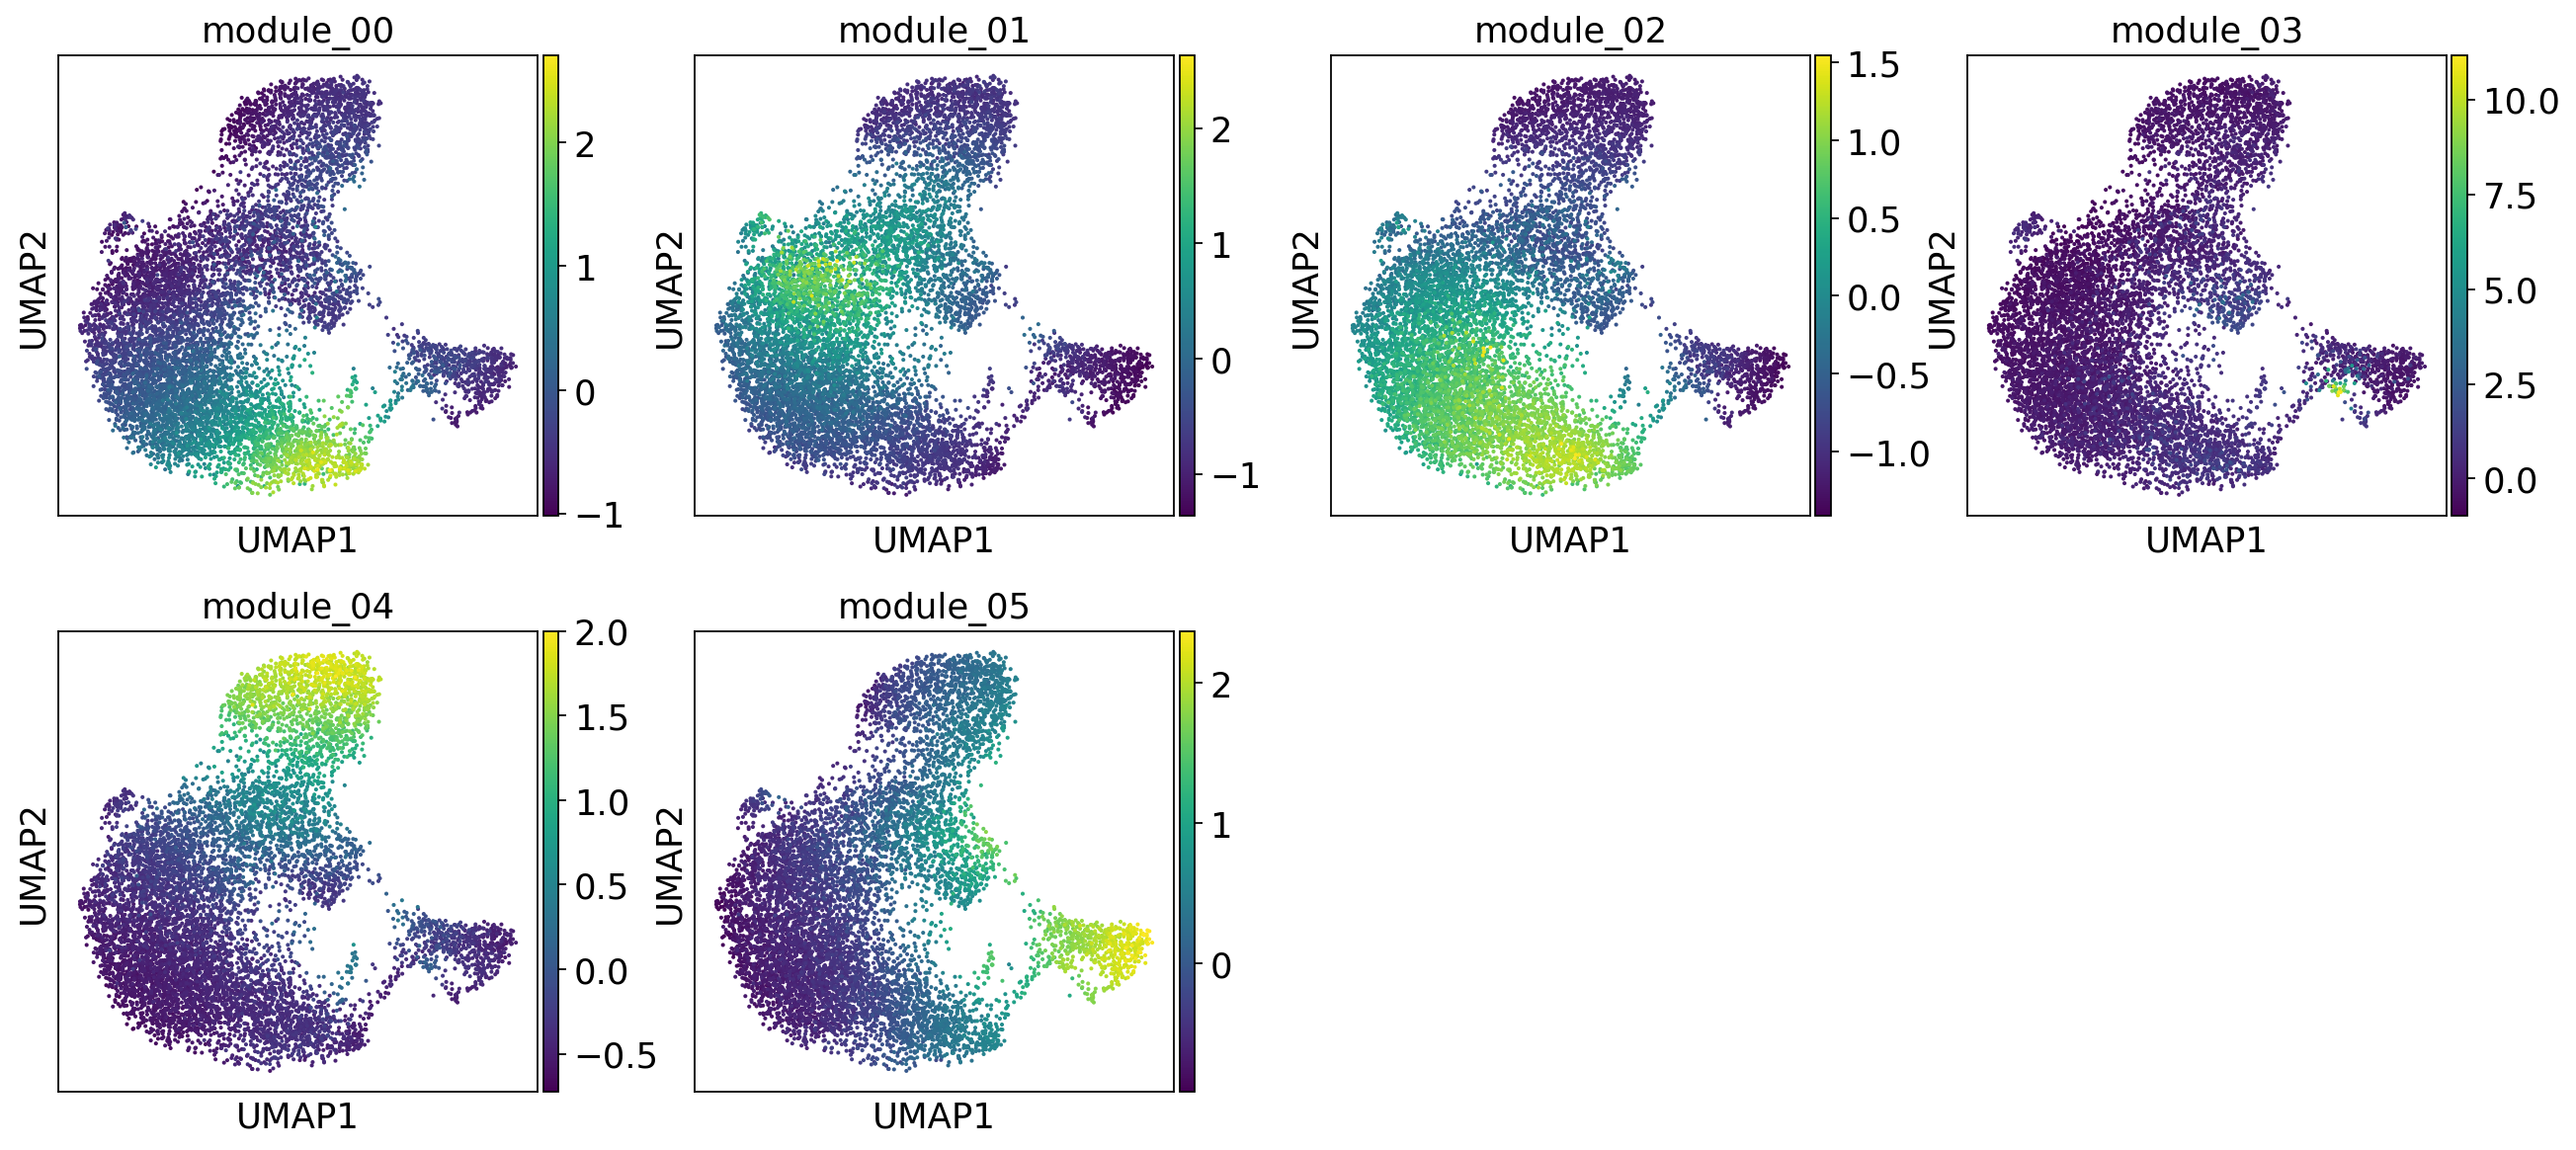

In [ ]:
sc.pl.umap(adata_TAM, color=['module_00', 'module_01', 'module_02', 'module_03', 'module_04', 'module_05'])

Module 3 is largely composed of collagens. I think this is a misclassification of cell types. I removed this module

In [ ]:
cliques_iterative[3]

['FZD1',
 'BMPR1A',
 'C3',
 'IL6RA',
 'ANGPTL2',
 'GHR',
 'POSTN',
 'RARRES2',
 'CXCL12',
 'IL33',
 'VEGFD']

In [ ]:
del cliques_iterative[3]
len(cliques_iterative)

5

In [ ]:
adata_TAM.layers['imputed_zscore'] = adata_TAM.layers['imputed'].copy()
sc.pp.scale(adata_TAM, layer = 'imputed_zscore')
for i in range(len(cliques_iterative)):
    adata_TAM.obs['module_' + str(i).zfill(2)] = np.ravel(adata_TAM[:,cliques_iterative[i]].layers['imputed_zscore'].mean(axis=1))

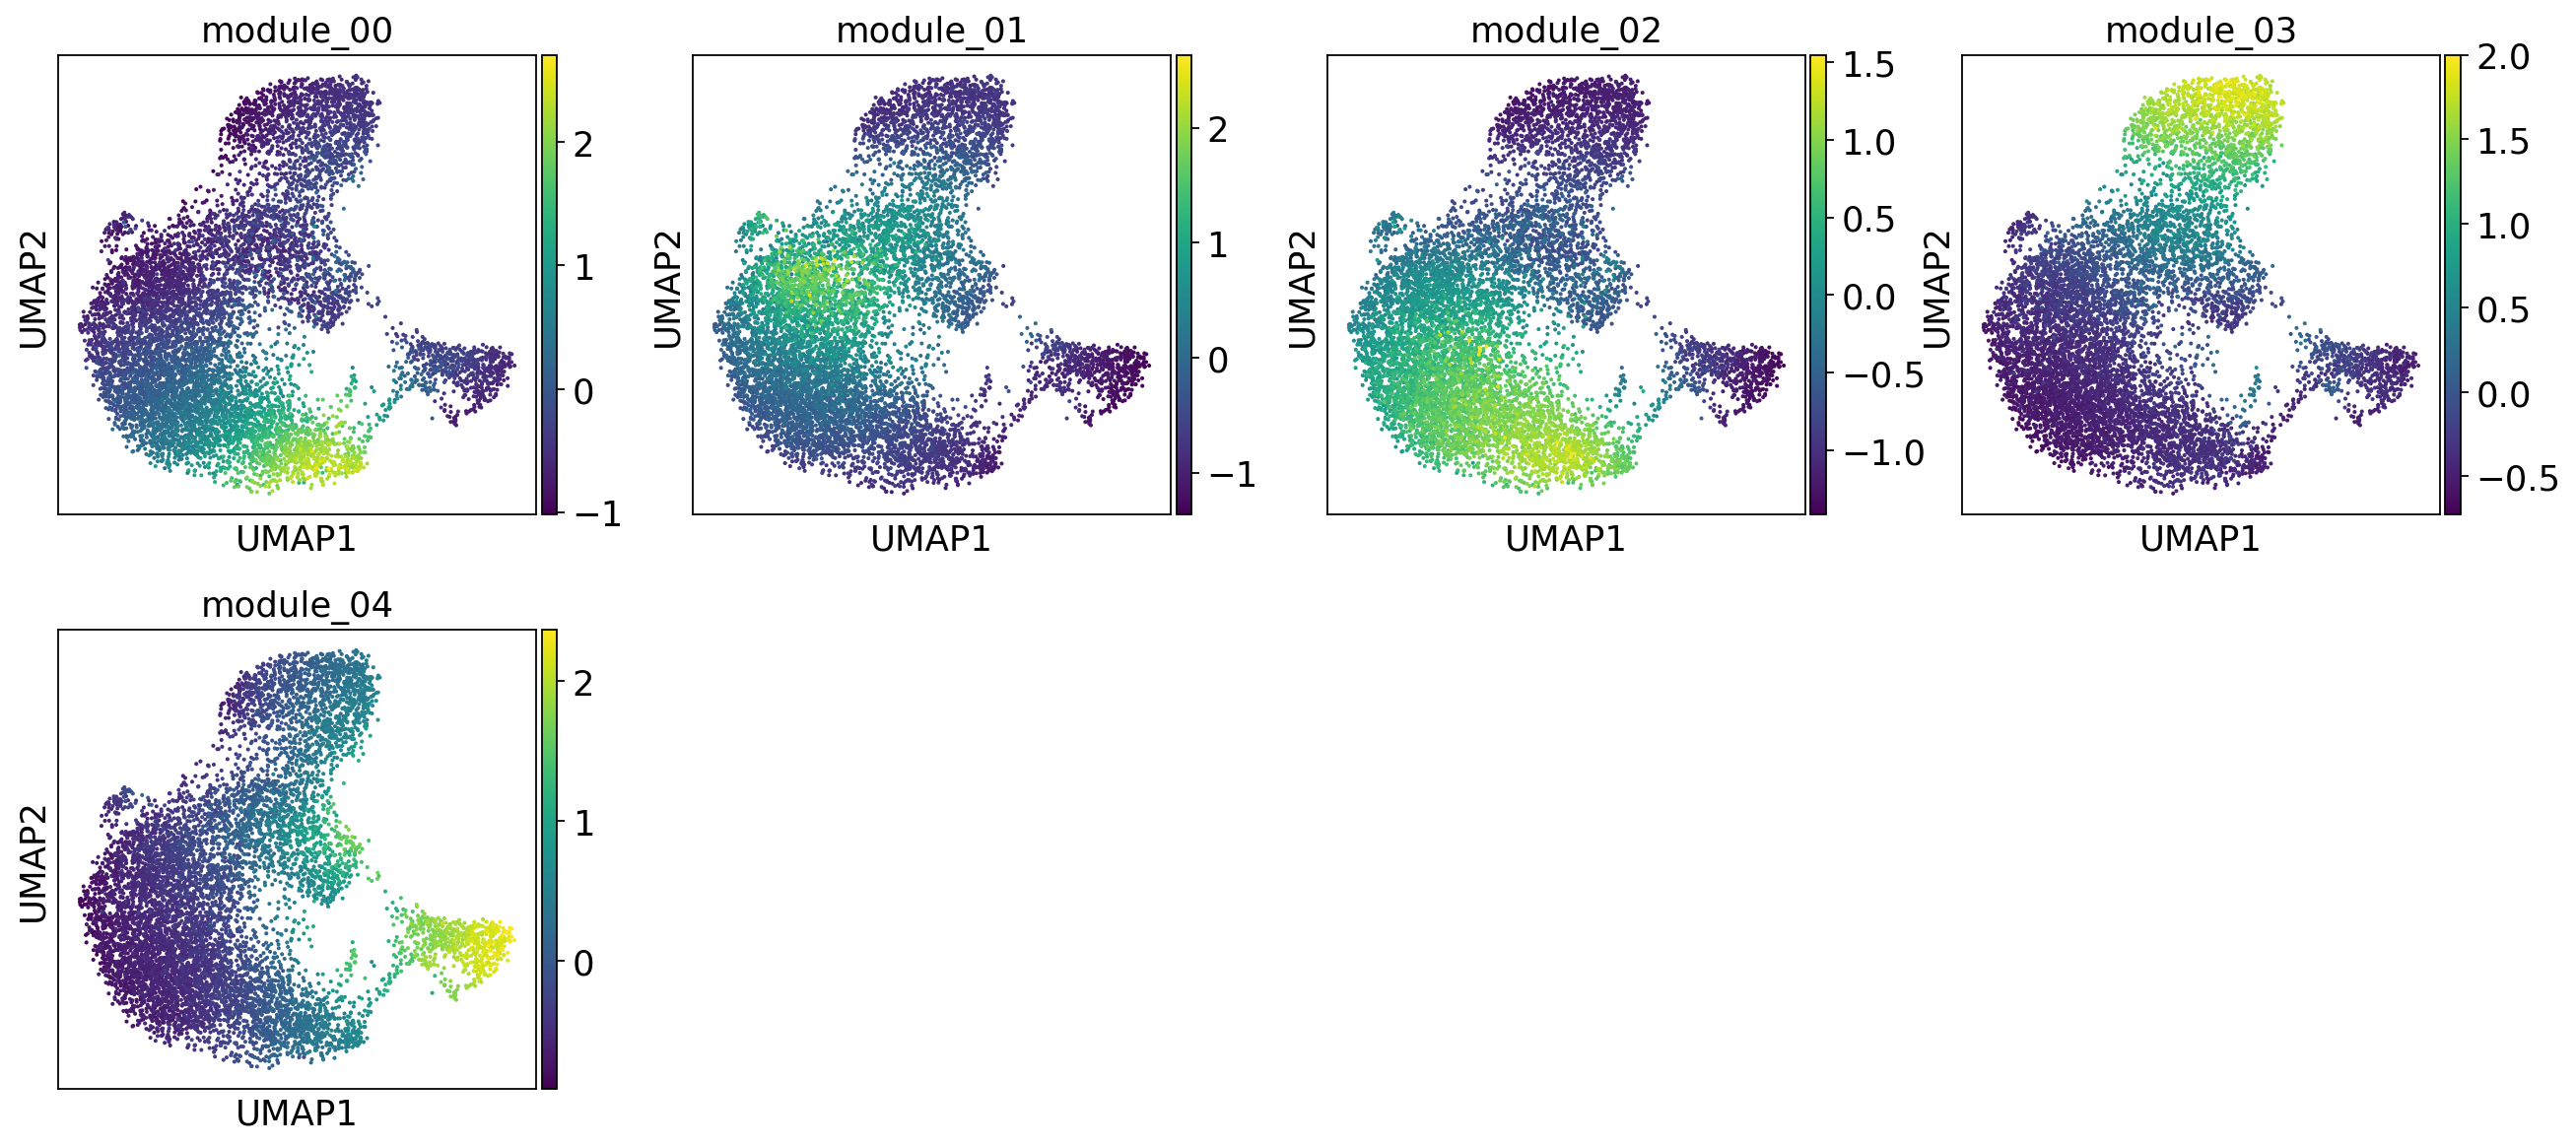

In [ ]:
sc.pl.umap(adata_TAM, color=[ 'module_00', 'module_01', 'module_02', 'module_03', 'module_04'])

In [ ]:
if 'imputed_zscore' in adata_TAM.layers:
    del adata_TAM.layers['imputed_zscore']
adata_temp = adata_TAM[:, selected_genes].copy()
sc.write(os.path.join(output_dir, re.sub(".h5ad", "__imputed.h5ad", current_filename)), adata = adata_temp)
result = {
    'corr_mat': corr_mat,
    'ordering': ordering,
    'cliques_iterative': cliques_iterative,
    'G': G,
    'G_pruned': Gpruned
}
write_object(result, os.path.join(output_dir, re.sub(".h5ad", "__communication_modules.pydata", current_filename)))

### Fibroblast communication modules

In [ ]:
current_filename = "Reyes_FLEX_SUBSET_fib_all__integrated.h5ad"
adata_fib = sc.read_h5ad(os.path.join(input_dir, current_filename))

Subset only myCAF

/data/lowe/reyesj3/miniconda3/envs/rapidsai/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


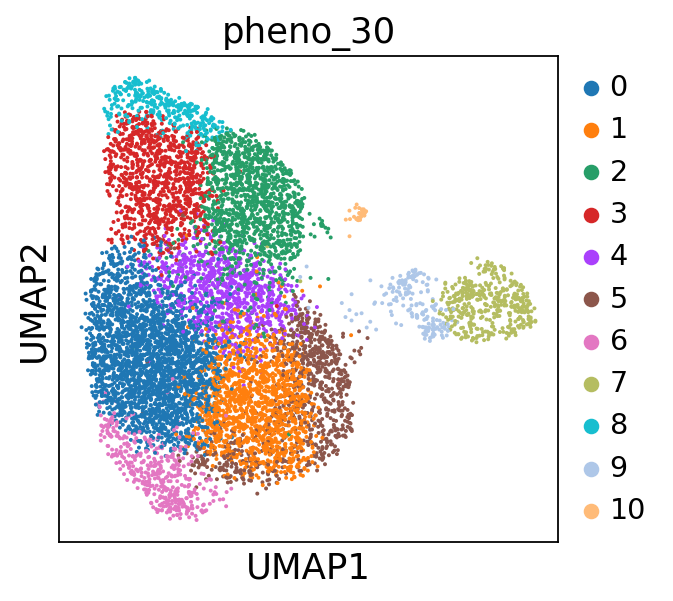

/data/lowe/reyesj3/miniconda3/envs/rapidsai/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


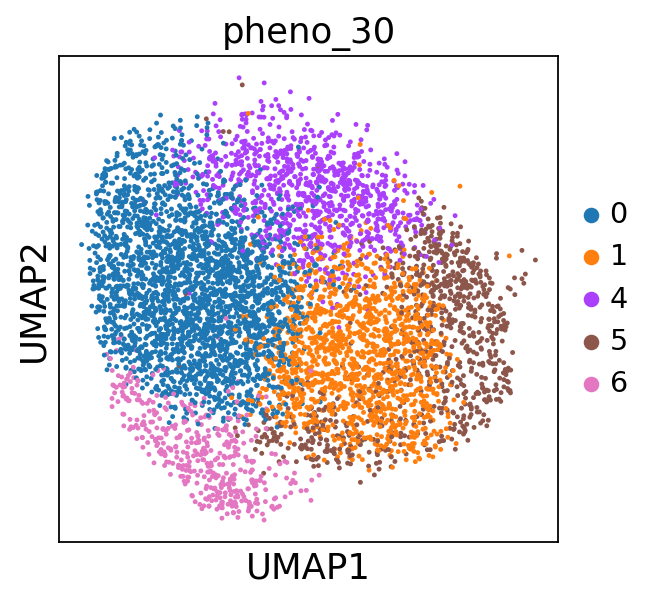

In [ ]:
sc.pl.umap(adata_fib, color='pheno_30')
adata_fib = adata_fib[ismember(adata_fib.obs['pheno_30'], [0,1,4,5,6])[1],:].copy()
sc.pl.umap(adata_fib, color='pheno_30')


In [ ]:
imputed_adata = get_imputed_adata_subset(adata_fib, ismember(adata_fib.obs['genotype'], ['ctrl', 'p53_knockdown'])[1], k = 30, t_steps=2)
imputed_adata.layers['zscore'] = np.array(imputed_adata.X.copy())
sc.pp.scale(imputed_adata, layer = 'zscore')

Getting knn graph
Getting diffusion operator
Computing diffusion kernel using CPU
Computing diffusion operator using CPU
Imputing data


Imputed expression filter: 226 genes
Local detection filter: 225 genes
Global detection filter: 267 genes
Final selected: 210 genes


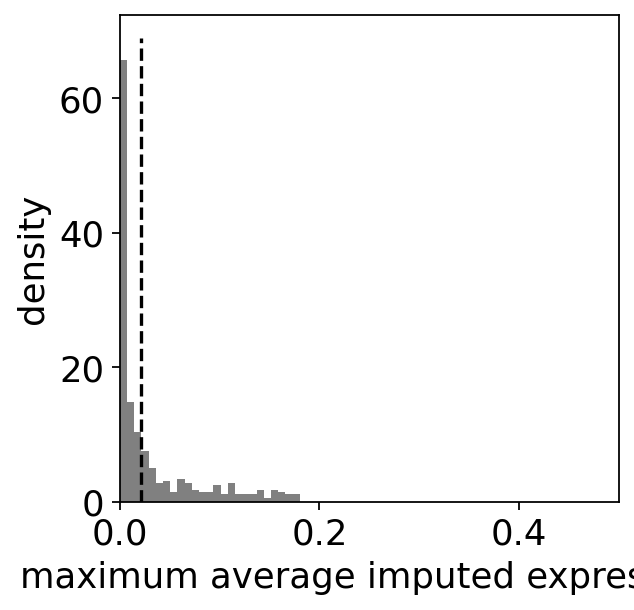

In [ ]:
adata_fib.layers['imputed'] = imputed_adata[adata_fib.obs_names,:].X.copy()
selected_genes = select_genes(adata_fib, hist_bins = 25, MIN_DETECTION_LOCAL=0.05, filter_global=True, MIN_DETECTION_GLOBAL=50)

In [ ]:
selected_genes

array(['ACKR3', 'ACKR4', 'ACVR1', 'ACVR1B', 'ACVR2A', 'ACVRL1',
       'ADCYAP1R1', 'ADIPOR1', 'ADIPOR2', 'ADM', 'AGTR1A', 'ANGPT1',
       'ANGPTL2', 'ANGPTL4', 'ANXA1', 'APLNR', 'ARTN', 'AXL', 'BAG6',
       'BMP4', 'BMP6', 'BMPR1A', 'BMPR2', 'C3', 'C4A', 'C4B', 'CALCRL',
       'CAP1', 'CCL11', 'CCL19', 'CD44', 'CD74', 'CDH11', 'CDH5',
       'CHRNB1', 'CLCF1', 'CMKLR1', 'CRLF2', 'CSF1', 'CSF1R', 'CSF2RA',
       'CSF2RB', 'CX3CL1', 'CXCL12', 'CXCL16', 'EDA2R', 'EDNRA', 'EGFR',
       'ERBB2', 'F2R', 'FAS', 'FGF1', 'FGF10', 'FGF18', 'FGF2', 'FGF7',
       'FGF9', 'FGFR1', 'FGFR2', 'FLT3L', 'FZD1', 'FZD2', 'FZD3', 'FZD4',
       'FZD5', 'FZD7', 'GAS6', 'GCG', 'GDF10', 'GDF6', 'GFRA2', 'GHR',
       'GRN', 'HGF', 'IFNAR1', 'IFNAR2', 'IFNGR1', 'IFNGR2', 'IGF1',
       'IGF1R', 'IGF2', 'IGF2R', 'IGFLR1', 'IGHM', 'IL10RB', 'IL11RA1',
       'IL13RA1', 'IL15', 'IL15RA', 'IL17RA', 'IL17RC', 'IL1R1', 'IL1RL2',
       'IL2RG', 'IL33', 'IL34', 'IL3RA', 'IL4RA', 'IL6', 'IL6ST', 'IL7',
       '

In [ ]:
blacklisted_genes = ['PECAM1', 'CDH1', 'CSF1R']
selected_genes = selected_genes[np.logical_not(ismember(selected_genes, blacklisted_genes)[1])]

In [ ]:
X = imputed_adata[:, selected_genes].layers['zscore']
corr_mat = np.corrcoef(X.T)
corr_mat = pd.DataFrame(corr_mat, index = selected_genes, columns = selected_genes)
linkage = hierarchy.linkage(corr_mat, method = 'ward')
ordering = hierarchy.dendrogram(linkage, no_plot = True)['leaves']

Constructing graph
Pruning graph
Computing modules


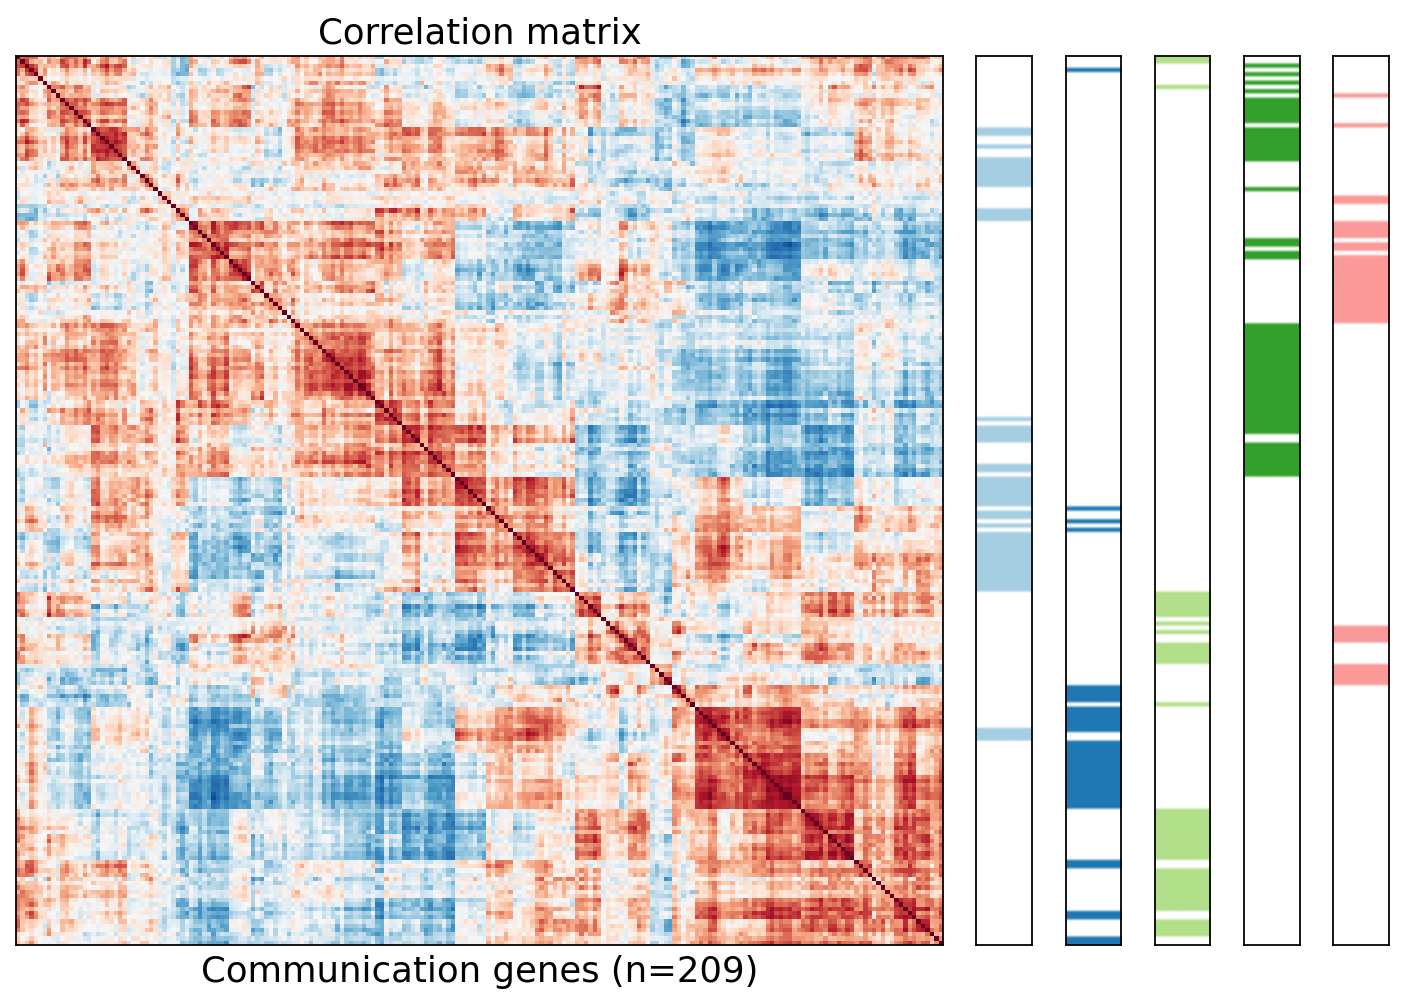

In [ ]:
cliques_iterative, G, Gpruned = get_modules(
    corr_mat.to_numpy(),corr_mat.index.to_numpy(),
    prune_thresh=0.05,prune_thresh_upper=0.95,correlation_threshold = 0.3
)
        
show_correlation_heatmap(
    corr_matrix = corr_mat, 
    ordering = ordering, 
    cliques = cliques_iterative, 
    use_labels = [], 
    selected_type = 'fib', 
    save_plot = False
)

In [ ]:
adata_fib.layers['imputed_zscore'] = adata_fib.layers['imputed'].copy()
sc.pp.scale(adata_fib, layer = 'imputed_zscore')
for i in range(len(cliques_iterative)):
    adata_fib.obs['module_' + str(i).zfill(2)] = np.ravel(adata_fib[:,cliques_iterative[i]].layers['imputed_zscore'].mean(axis=1))

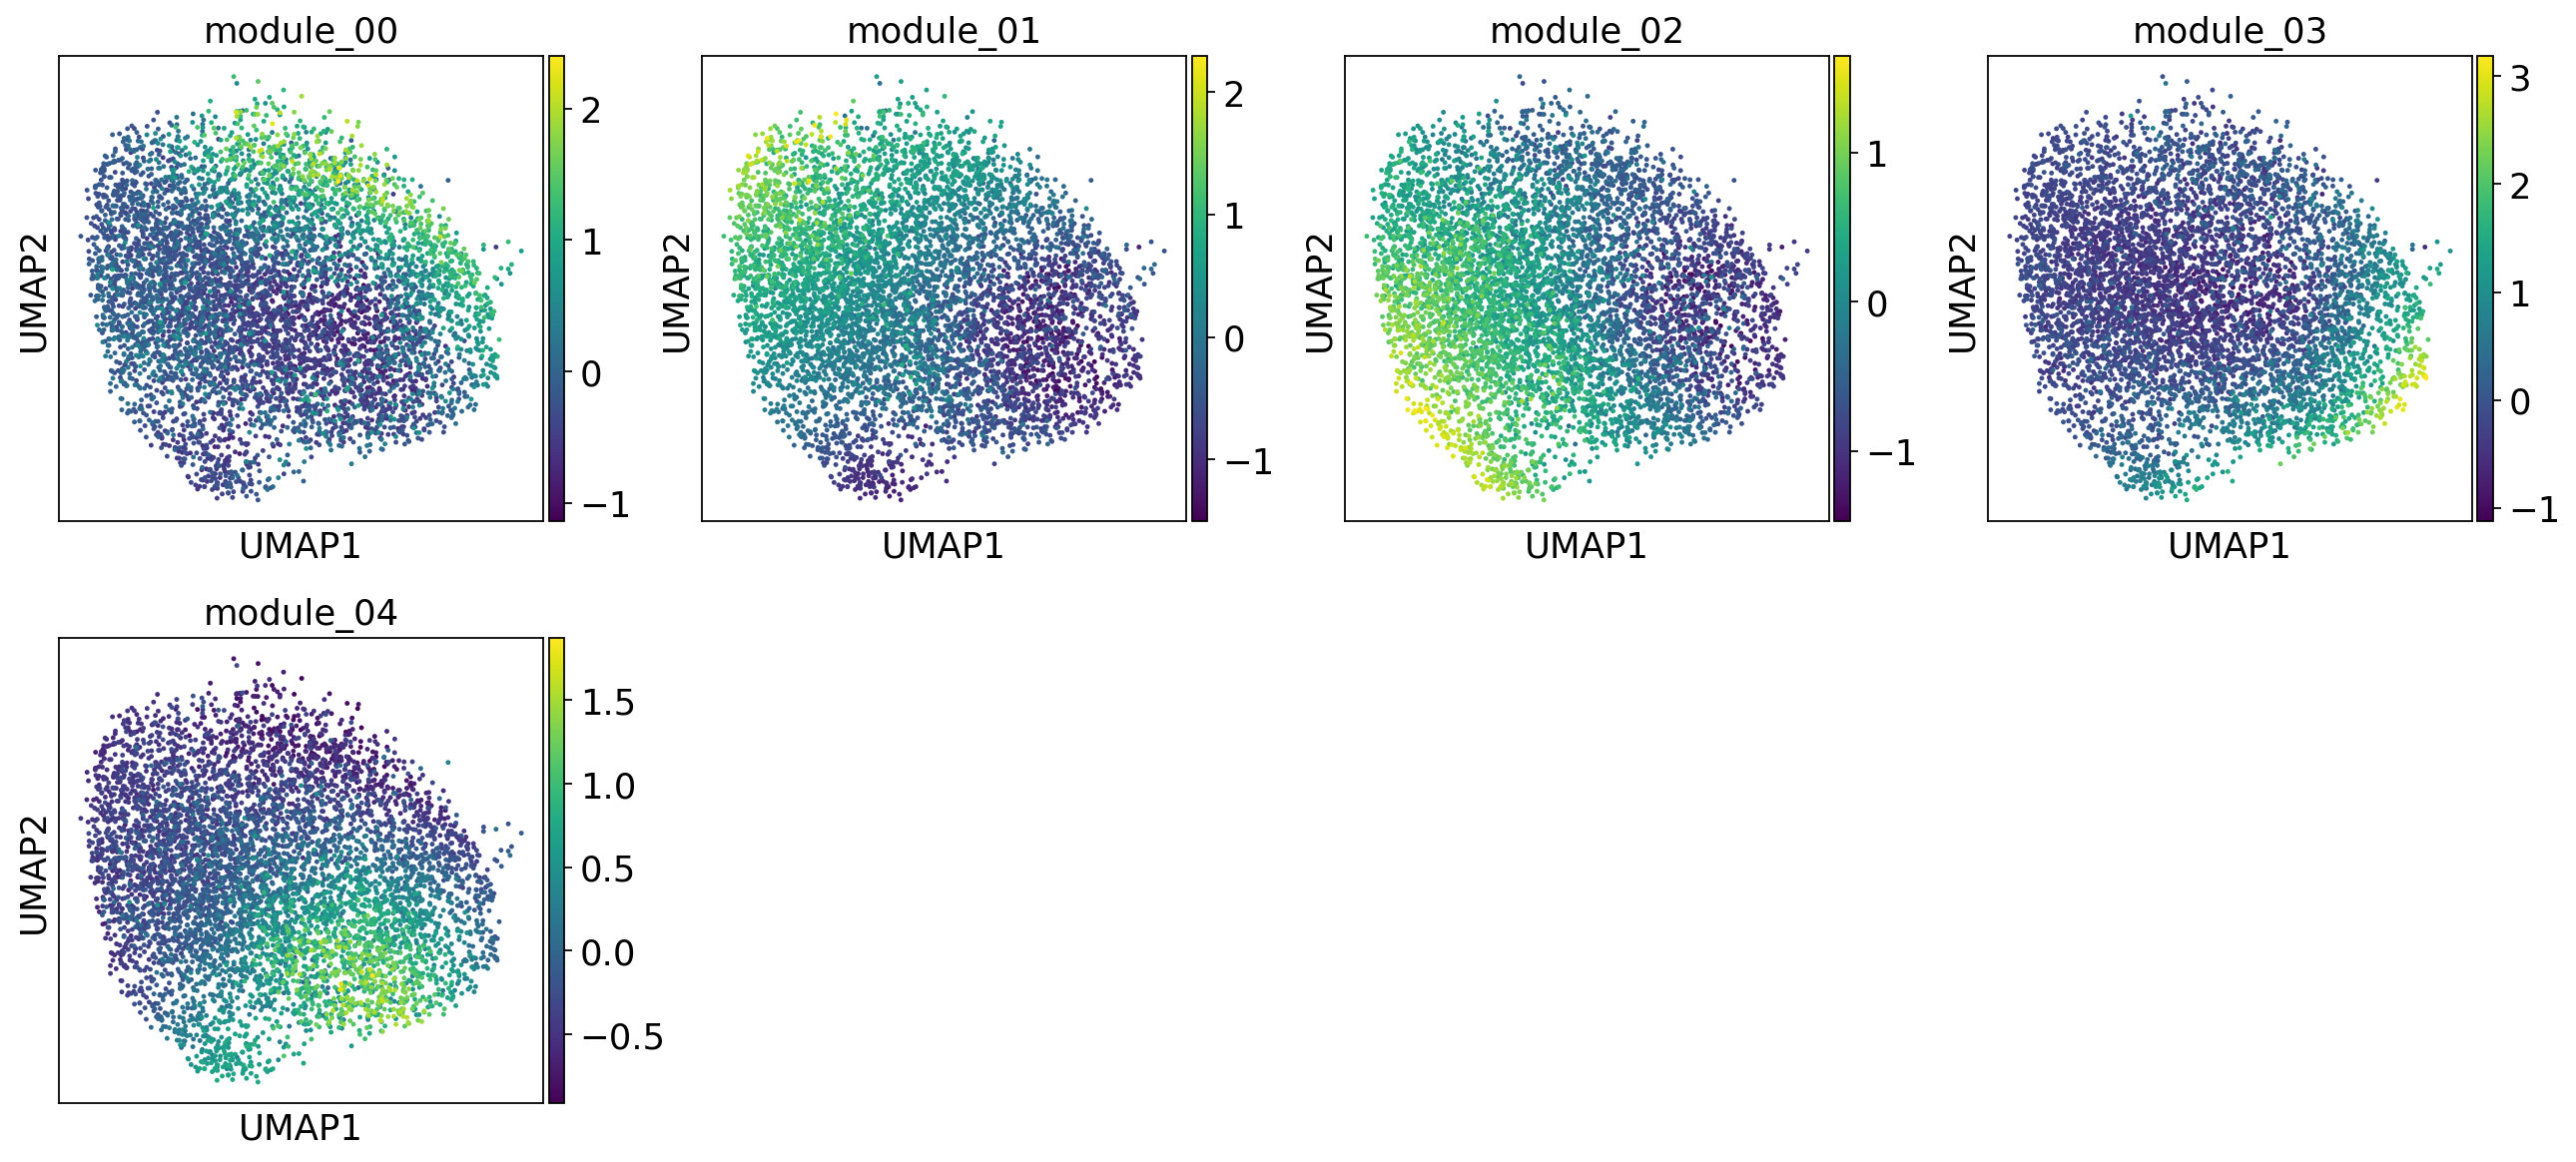

In [ ]:
sc.pl.umap(adata_fib, color=[ 'module_00', 'module_01', 'module_02', 'module_03', 'module_04'])

In [ ]:
np.sort(cliques_iterative[3])

array(['ACVR1', 'ADIPOR1', 'ANXA1', 'BMPR1A', 'BMPR2', 'CAP1', 'CD44',
       'CD74', 'CDH11', 'CLCF1', 'CMKLR1', 'CRLF2', 'FAS', 'FZD1', 'FZD3',
       'IFNAR1', 'IFNGR2', 'IL13RA1', 'IL1RL2', 'IL2RG', 'IL34', 'ITGA5',
       'ITGA9', 'ITGAV', 'ITGB1', 'ITGB3', 'ITGB4', 'ITGB5', 'LEPR',
       'LGALS9', 'LTBR', 'MCAM', 'NPR2', 'NRP2', 'PARD3', 'PDGFA',
       'PDGFRB', 'PLXNA2', 'PLXND1', 'POSTN', 'SDC1', 'SDC2', 'SDC3',
       'SMO', 'SPP1', 'TGFB1', 'TGFB2', 'TGFBR1', 'TGFBR2', 'TNFRSF11B',
       'TNFRSF12A', 'TNFRSF1A', 'TNFSF4', 'UCN2', 'WNT11', 'WNT2',
       'WNT9A'], dtype='<U9')

In [ ]:
if 'imputed_zscore' in adata_fib.layers:
    del adata_fib.layers['imputed_zscore']
adata_temp = adata_fib[:, selected_genes].copy()
sc.write(os.path.join(output_dir, re.sub(".h5ad", "__imputed.h5ad", current_filename)), adata = adata_temp)
result = {
    'corr_mat': corr_mat,
    'ordering': ordering,
    'cliques_iterative': cliques_iterative,
    'G': G,
    'G_pruned': Gpruned
}
write_object(result, os.path.join(output_dir, re.sub(".h5ad", "__communication_modules.pydata", current_filename)))

### Calligraphy

In [ ]:
import itertools
ligands = [re.split("_", x.upper()) for x in rl_database.iloc[:,0]]
receptors = [re.split("_", x.upper()) for x in rl_database.iloc[:,1]]

ligand_receptor_pairs = []
for ligand_collection, receptor_collection in zip(ligands, receptors):
    ligand_receptor_pairs += list(itertools.product(ligand_collection, receptor_collection))
ligand_receptor_pairs = np.array(ligand_receptor_pairs)
ligand_receptor_pairs = np.unique(ligand_receptor_pairs, axis=0)

unique_ligands = np.unique(ligand_receptor_pairs[:,0])
unique_receptors = np.unique(ligand_receptor_pairs[:,1])
ligand_index = ismember(ligand_receptor_pairs[:,0], unique_ligands)[0]
receptor_index = ismember(ligand_receptor_pairs[:,1], unique_receptors)[0]
LR_graph = scipy.sparse.csr_matrix(([1]*ligand_receptor_pairs.shape[0], (ligand_index, receptor_index)), shape = [len(unique_ligands), len(unique_receptors)])

In [ ]:
def get_interaction_count(clique_sender, clique_receiver):
    subgraph = LR_graph[ismember(unique_ligands, clique_sender)[1],:][:,ismember(unique_receptors, clique_receiver)[1]]
    return subgraph.sum().sum()

def get_clique_dictionary(cliques_list, labels):
    clique_dictionary = dict()
    for my_cliques, my_label in zip(cliques_list, labels):
        for i, current_clique in enumerate(my_cliques):
            clique_dictionary[my_label + "_" + str(i)] = current_clique
    return(clique_dictionary)

def get_pairwise_interaction_count(my_dict):
    clique_keys = list(my_dict.keys())
    result = dict()
    for sender, receiver in itertools.product(clique_keys, clique_keys):
        #if sender == receiver:
        #    continue
        result[sender + "__" + receiver] = get_interaction_count(my_dict[sender], my_dict[receiver])
    return(result)

def shuffle_cliques(cliques_list):
    #cliques_list: nested array-like with dimension==number of subsets, each a list containing lists of the genes in each module for that subset
    cliques_list_new = []
    for cliques in cliques_list:
        cliques_full = np.concatenate(cliques)
        np.random.shuffle(cliques_full)
        cliques_new = []
        i=0
        test = np.arange(len(cliques_full))
        for cl in cliques:
            cliques_new.append(cliques_full[i:i+len(cl)])
            i+=len(cl)
        cliques_list_new.append(cliques_new)
    return cliques_list_new

import itertools
import collections

def test_interactions(cliques_list, labels, ntrials = 5000):
    observed_dict = get_clique_dictionary(cliques_list, labels)
    observed = get_pairwise_interaction_count(observed_dict)
    
    expected = collections.defaultdict(list)
    for i in tqdm(range(ntrials)):
        cliques_shuffled = shuffle_cliques(cliques_list)
        shuffled_dict = get_clique_dictionary(cliques_shuffled, labels)
        expected_counts = get_pairwise_interaction_count(shuffled_dict)
        for my_path in expected_counts.keys():
            expected[my_path].append(expected_counts[my_path])
    
    pvalue = dict()
    ratio = dict()
    for my_path in observed.keys():
        current_value = observed[my_path]
        null_distribution = np.array(expected[my_path])
        pvalue[my_path] = np.mean(null_distribution >= current_value) #p-value
        ratio[my_path] = current_value/np.mean(null_distribution) #ratio of observed to average of expected
    
    all_keys = list(observed.keys())
    result_final = pd.DataFrame({
        'p-value': [pvalue[x] for x in all_keys],
        'ratio': [ratio[x] for x in all_keys],
        'observed_counts': [observed[x] for x in all_keys]
    },index = all_keys
    ).sort_values(by = 'p-value')
    return(result_final)

In [ ]:
#function to shuffle the genes in each module for the random null distribution
#generate a directed networkx graph from given modules and a database of known cognate interactions between genes
#Note: this will add two edges for each gene in an overlapping module!
def generate_graph(cliques_list,cliques_list_labels,ligand_receptor_pairs):
    #cliques_list: nested array-like with dimension==number of subsets, each a list containing lists of the genes in each module for that subset
    #cliques_list_labels: array-like of names as strings to assign to each subset
    #RL_pairs: dictionary of cognate R-L interactions.
    
    #this function creates a separate node for each module in each subset and labels them j_subset
    #where j indexes the TOTAL number of modules from 1.
    
    #it stores for each node an attribute "genes" storing a list of the genes in that module
    
    #intragraph: generating a node for each module with size proportional to number of genes in that node
    G_all = nx.DiGraph()
    labels = {} #dict mapping module names to names in networkx graph
    node_sizes = [] #list of node sizes
    node_genes = {} #dict of genes per node
    
    for cliques, my_label in zip(cliques_list, cliques_list_labels):
        for i,cl in enumerate(cliques):
            clique_name = "{}_{}".format(my_label, i)
            G_all.add_node(clique_name,genes=cl)
            node_genes[clique_name] = cl
            node_sizes.append(len(cl))
            labels[clique_name] = clique_name
    edge_attrs = {}
    clique_names = list(G_all)
    for clique1, clique2 in itertools.product(clique_names, clique_names):
        genes_1 = node_genes[clique1]
        genes_2 = node_genes[clique2]
        # Ligands and receptors in clique 1
        ligands_1 = np.intersect1d(genes_1, ligand_receptor_pairs[:,0])
        receptor_1 = np.intersect1d(genes_1, ligand_receptor_pairs[:,1])
        # Ligands and receptors in clique 2
        ligands_2 = np.intersect1d(genes_2, ligand_receptor_pairs[:,0])
        receptor_2 = np.intersect1d(genes_2, ligand_receptor_pairs[:,1])
        # Examine possible receptors for ligands in clique1
        # This fails if ligands_1 is empty
        try:
            cognate_receptor_1 = ligand_receptor_pairs[ismember(ligand_receptor_pairs[:,0], ligands_1)[1],:]
            cognate_receptor_1 = cognate_receptor_1[ismember(cognate_receptor_1[:,1], receptor_2)[1],:]
            G_all.add_edge(clique1,clique2,width=cognate_receptor_1.shape[0],color='k')
            edge_attrs[(clique1,clique2)] = {"genes_pairs": ['_'.join(x) for x in cognate_receptor_1]}
        except:
            pass
        # Examine possible ligands for receptors in clique1
        # This fails if receptor_1 is empty
        try:
            cognate_ligands_1 = ligand_receptor_pairs[ismember(ligand_receptor_pairs[:,1], receptor_1)[1],:]
            cognate_ligands_1 = cognate_ligands_1[ismember(cognate_ligands_1[:,0], ligands_2)[1],:]
            G_all.add_edge(clique2,clique1,width=cognate_ligands_1.shape[0],color='k')
            edge_attrs[(clique2,clique1)] = {"genes_pairs": ['_'.join(x) for x in cognate_ligands_1]}
        except:
            pass
    G = G_all
    
    nx.set_edge_attributes(G_all, edge_attrs)                
    return G_all,node_sizes,node_genes

In [ ]:
grep("communication", os.listdir(output_dir))

array(['Reyes_SourceData_injury_shp53__communication_modules.pydata',
       'FLEX_SUBSET_fib_FigSX_embed__communication_modules.pydata',
       'FLEX_SUBSET_premalignant_FigSX_embed__communication_modules.pydata',
       'FLEX_SUBSET_TAM_FigSX_embed__communication_modules.pydata'],
      dtype='<U66')

In [ ]:
result_epi = read_object(os.path.join(output_dir, 'Reyes_injury_SUBSET_all__annotated__communication_modules.pydata'))
suffix = 'dissociatedEpi'

result_TAM = read_object(os.path.join(output_dir, 'Reyes_FLEX_SUBSET_TAM_all__integrated__communication_modules.pydata'))
result_fib = read_object(os.path.join(output_dir, 'Reyes_FLEX_SUBSET_fib_all__integrated__communication_modules.pydata'))

cliques_epi = result_epi["cliques_iterative"].copy()
cliques_TAM = result_TAM["cliques_iterative"].copy()
cliques_fib = result_fib["cliques_iterative"].copy()

cliques_list = [cliques_epi,cliques_fib,cliques_TAM]
clique_labels = ['epi','fib','myeloid']

G,node_sizes,node_genes = generate_graph(
    [cliques_epi,cliques_fib,cliques_TAM],
    ['epi','fib','myeloid'],
    ligand_receptor_pairs)

In [ ]:
results_df = test_interactions(cliques_list, clique_labels)

100%|██████████| 5000/5000 [13:47<00:00,  6.04it/s]


In [ ]:
result_calligraphy = {
    'G': G,
    'cliques_list' : cliques_list,
    'cliques_list_labels': clique_labels,
    'calligraphy_result': results_df
}
write_object(result_calligraphy, os.path.join(output_dir, "result_calligraphy_imputed_T2_" + suffix + ".pydata"))